# XRD Intensity Visualization

This notebook downloads processed XRD intensity curves for a single sample (IGSN) and overlays them on one plot. It uses `xrd_derived` files with `xrd.csv` in their name, which contain 2theta and intensity values.

Steps:
1. Use `/aimdl/partition` to find all IGSNs that have XRD derived data
2. Choose a target IGSN
3. Download its `xrd.csv` files into memory
4. Plot 2theta vs. intensity for all scans on one figure

In [1]:
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from aimdl_examples import (
    get_girder_client,
    get_item_to_memory,
)

## Find samples with XRD data

Use `/aimdl/partition` to get the list of IGSNs that have at least one `xrd_derived` file. This is faster than scanning all items — the partition endpoint returns only the IGSN strings.

In [2]:
with requests.Session() as session:
    gc = get_girder_client(session=session)
    partitions = gc.get('aimdl/partition', parameters={'dataType': 'xrd_derived'})

# The response is a dict keyed by IGSN
igsn_list = list(partitions)
print(f'Found {len(igsn_list)} IGSNs with xrd_derived data')
print('All IGSNs:', igsn_list)

Found 991 IGSNs with xrd_derived data
All IGSNs: ['APLMAD00001//2026-04-27T19:33:29+00:00', 'APLMAJ00005-01//2025-10-23T15:47:38+00:00', 'APLMAJ00005-01//2025-10-23T16:45:46+00:00', 'APLMAJ00005-01//2025-10-24T21:37:19+00:00', 'APLMAJ00005-01//2025-10-24T22:25:07+00:00', 'APLMAJ00005//2025-10-09T16:21:03+00:00', 'APLMAJ00005//2025-10-09T17:10:02+00:00', 'APLMAJ00005//2025-10-09T18:47:08+00:00', 'APLMAJ00005//2025-10-09T20:20:32+00:00', 'APLMAJ00005//2025-10-09T22:42:02+00:00', 'APLMAJ00005//2025-10-30T16:48:30+00:00', 'APLMAJ00005//2025-10-30T17:51:57+00:00', 'APLMAJ00005//2025-10-30T17:58:00+00:00', 'APLMAJ00005//2025-10-30T18:01:26+00:00', 'APLMAJ00005//2025-10-30T18:08:39+00:00', 'APLMAJ00005//2025-10-30T18:15:57+00:00', 'APLMAJ00005//2025-10-30T18:22:36+00:00', 'APLMAJ00005//2025-10-30T18:32:08+00:00', 'APLMAJ00005//2025-10-30T18:37:14+00:00', 'APLMAJ00005//2025-10-30T18:48:34+00:00', 'APLMAJ00005//2025-10-30T19:53:13+00:00', 'APLMAJ00005//2025-10-30T20:01:19+00:00', 'APLMAJ00005//

## Choose a target IGSN

Set `TARGET_IGSN` to any IGSN from the list above. The default picks the first one.

In [3]:
TARGET_IGSN = igsn_list[0]  # or set a specific IGSN, e.g. 'JHAMAL00016-002'
print('Target IGSN:', TARGET_IGSN)

Target IGSN: APLMAD00001//2026-04-27T19:33:29+00:00


## Find XRD intensity files for this sample

Use the `/aimdl/partition/details` endpoint with the target IGSN to retrieve all xrd_derived items for that sample, then filter client-side for `xrd.csv` files.

In [4]:
def is_target_xrd_csv(item):
    return 'xrd.csv' in item.get('name', '')

with requests.Session() as session:
    gc = get_girder_client(session=session)
    
    # Get partition details for this IGSN to retrieve xrd_derived items
    details = gc.get('aimdl/partition/details', parameters={
        'key': TARGET_IGSN,
        'dataType': 'xrd_derived',
    })
    
    # Filter for xrd.csv files
    items = [item for item in details if is_target_xrd_csv(item)]

print(f'Found {len(items)} xrd.csv files for {TARGET_IGSN}')
for item in items:
    print(' -', item['name'])

Found 29 xrd.csv files for APLMAD00001//2026-04-27T19:33:29+00:00
 - scan_point_25_azimuthal_xrd.csv
 - scan_point_10_azimuthal_xrd.csv
 - scan_point_13_azimuthal_xrd.csv
 - scan_point_1_azimuthal_xrd.csv
 - scan_point_9_azimuthal_xrd.csv
 - scan_point_27_azimuthal_xrd.csv
 - scan_point_3_azimuthal_xrd.csv
 - scan_point_18_azimuthal_xrd.csv
 - scan_point_19_azimuthal_xrd.csv
 - scan_point_26_azimuthal_xrd.csv
 - scan_point_14_azimuthal_xrd.csv
 - scan_point_21_azimuthal_xrd.csv
 - scan_point_16_azimuthal_xrd.csv
 - scan_point_20_azimuthal_xrd.csv
 - scan_point_28_azimuthal_xrd.csv
 - scan_point_23_azimuthal_xrd.csv
 - scan_point_15_azimuthal_xrd.csv
 - scan_point_22_azimuthal_xrd.csv
 - scan_point_7_azimuthal_xrd.csv
 - scan_point_8_azimuthal_xrd.csv
 - scan_point_0_azimuthal_xrd.csv
 - scan_point_2_azimuthal_xrd.csv
 - scan_point_11_azimuthal_xrd.csv
 - scan_point_12_azimuthal_xrd.csv
 - scan_point_4_azimuthal_xrd.csv
 - scan_point_17_azimuthal_xrd.csv
 - scan_point_5_azimuthal_xrd.cs

## Download and inspect

Stream each CSV into memory using `get_item_to_memory`. The exact column names depend on how the data was processed — we print them so you know what to plot.

In [5]:
scans = {}
with requests.Session() as session:
    gc = get_girder_client(session=session)
    for item in items:
        content = b''.join(get_item_to_memory(gc, item))
        scans[item['name']] = pd.read_csv(io.BytesIO(content))

if not scans:
    raise RuntimeError(f'No xrd.csv files downloaded for {TARGET_IGSN}. Re-run the cell above to check how many items were found.')

first = next(iter(scans.values()))
print('Columns:', list(first.columns))
print(f'Rows per scan: {len(first)}')
first.head()

Columns: ['q_nm^-1', 'intensity']
Rows per scan: 10000


,q_nm^-1,intensity
0,0.002950,26.542353
1,0.008851,27.450048
2,0.014752,25.910208
3,0.020653,24.672770
4,0.026554,24.419498


## Plot 2theta vs. intensity

Overlay all scans for this sample on one figure. Adjust `TWO_THETA_COL` and `INTENSITY_COL` if the column names differ from what's shown above.

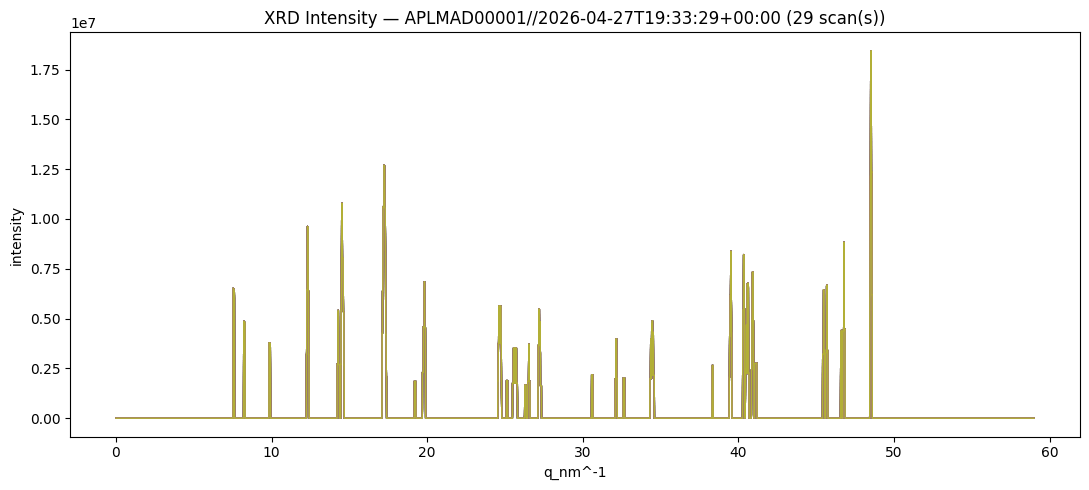

In [6]:
# Update these if the actual column names differ
TWO_THETA_COL = first.columns[0]
INTENSITY_COL = first.columns[1]

fig, ax = plt.subplots(figsize=(11, 5))
for name, scan_df in scans.items():
    ax.plot(
        scan_df[TWO_THETA_COL],
        scan_df[INTENSITY_COL],
        label=name,
        alpha=0.8,
        linewidth=1,
    )

ax.set_xlabel(TWO_THETA_COL)
ax.set_ylabel(INTENSITY_COL)
ax.set_title(f'XRD Intensity — {TARGET_IGSN} ({len(scans)} scan(s))')
if len(scans) <= 10:
    ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()